#Goal

Classify images from drone overflights of a marsh. Images are 2x2 meters (47x47 pixels). Current labels are:

* Spartina Alterniflora - Tall Form (RFM Sub-label 01)
* Cynosuroides (label: 17)
* Cynosuroides & Shrub (label: 18)
* Cynosuroides & Phrag (label: 19)
* Spartina Patens & Distichlis Spicata (RFM Sub-label 06)
* Bull Rush (label: 20)
* Phragmites (RFM sub-label 12)
* Other (label: 99)

We would like to detect label 17 which is the habitat for Terrapins.  Label 1 and label 12 may also be of interest.  Note: label 1 is very similar looking to label 17, and is the grass that is taking over label 17, thus decrease the terrapins' habitat.

#Approach

What has worked best to date is a two-stage model.

* Stage 1. Combine label 1 and 17 (grasses) into one class (class 1), and everything else into another class (class 0). So end up with 2 classes total. Train. In essence, train to identify grasses regardless if whether it is the correct turtle habit grasses. If successful, this gives us the denominator of the metric, i.e., total number of grasses in the marsh.

* Stage 2. Build a separate model that focuses solely on classes 1 and 17. In essence, throw out other classes making it a binary problem. If successful, this gives us the numerator of the metric, i.e., a count of grasses where turtles eat/live.

To date, this has worked very well in terms of precision, recall, accuracy.

#This notebook focuses on Stage 1

The goal is to produce a Stage 1 model that can be saved and then used in Stage 2.

#Notes

##From salt marsh project (update once convert to turtles):

Assumes have access to numpy array of image files in a folder. Ballpark is 14000 images for a 2x2 meter image of the marsh. A separate notebook processes the raw tiff images and builds the numpy array.

The numpy image sets (each in individual folders) come in different varieties:

* Digital Elevation Model (DEM) are grayscale. As an aside, these have proven the most useful.

* RGB. Three bands.

* RGB+NIR+RE. Five bands. Near Infrared, Red Edge.

Assumes have access to csv file that provides labels for the tiff files in a folder. Most files will be unlabeled.

Assumes want to use Inception hence have RGB images (possibly colormapped grayscale). At moment not using NIR or RE if available.

Assumes image set may be too large to store in memory at once for training. Hence, uses a tensorflow trick that stores images to local Colab storage and reads it in in batches during training. Slows things down but better than running out of memory.

General idea here is to read in a cvs of training files with their labels, train-test split, then build a new numpy array of images for training and testing.

* Does augmentation of only the target class 1 to help with the heavily unbalanced dataset (very few class 1).

* Runs InceptionV3 with dense backend.

* Runs trained model on test set and shows results.

* Use Precision-Recall AUC for results.

* Saving model to file (if it is good :)



In [ ]:
#This is bloated - some of these libraries unused and some duplicated

import tensorflow as tf
from tensorflow.keras import mixed_precision
import os, sys
import shutil

from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout,  BatchNormalization, Activation, Concatenate, Input, Lambda

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1, l2, l1_l2

from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

import numpy as np
import json
import matplotlib.pyplot as plt
import random, pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import Callback
import pickle
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score

from tensorflow.keras.applications.inception_v3 import preprocess_input, decode_predictions
import cv2
from scipy.ndimage import gaussian_filter

from tensorflow.keras.applications.inception_v3 import preprocess_input


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Resizing, GlobalAveragePooling2D, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight
from tensorflow.keras.initializers import HeNormal

In [ ]:
print(tf.__version__)

2.18.0


###GPU helps but note determinism screws up GPU usage

So commenting it out. This means cannot exactly replicate results on duplicate runs. Currently you can access GPU or choose replication. I am choosing the GPU for speed. I do attempt to take as much randomness out of training as possible, but using a GPU will add some back in.

In [ ]:
tf.keras.utils.set_random_seed(1234)  #need this for replication
#tf.config.experimental.enable_op_determinism()  #ditto - https://www.tensorflow.org/api_docs/python/tf/config/experimental/enable_op_determinism
np.random.seed(seed=1234)
tf.random.set_seed(1234)  #global seed

In [ ]:
ngpus = len(tf.config.list_physical_devices('GPU'))
if ngpus > 0:
  mixed_precision.set_global_policy('mixed_float16')
  print(f"Num GPUs Available: {ngpus} - using mixed_precision")


Num GPUs Available: 1 - using mixed_precision


#Access to my data on Drive

New turtle grasses data:
https://drive.google.com/drive/u/0/folders/17lEgPixMQ5zzSQ_8HjkHiINirv3WhHvL




###Sites (maybe repurpose for different sets of tiles (thresholds vs centroid, etc.)

Second item of tuple is a a pair of values. The second is the original attribute table labeled by Kayla and Jade. The first is a revised version that includes hand-labeling images with high uncertainty for classes 0 and 1 (see active learning notebook).

The first item may not exist - no one has done the hand-labeling under uncertainty yet.

In [ ]:
#sites = (('/', ('training_labels.csv', 'training_labels.csv')),)  #Only data we have so far

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
epa_base = '/content/drive/MyDrive/epa_turtles_manual_output/' #this is a shortcut in my drive to Steve's drive

Mounted at /content/drive


###Just a demo of reading labels and what they look like

In [ ]:
training_labels = pd.read_csv(epa_base+'training_labels_rgb_47_centroid_7.csv') #training_labels.csv
print(training_labels['label'].value_counts(dropna=False))

label
NaN      495343
99.0      11290
12.0       1103
6.0         960
17.0        303
1.0         302
199.0       282
20.0         26
18.0         14
19.0          7
Name: count, dtype: int64


#These are the numpy arrays of images (as well as list csv of labels)

Note that they are varied in square pixels. Depending on the drone camera, a 2x2 meter patch may take up varying pixel sizes, e.g., 47x47 pixels. Some of the images have been left in raw form but many others have been upscaled to 299x299 pixels by the time we see them.

InceptionV3 will take up to 299x299. If an image is smaller, we have to upscale it here.

In [ ]:
image_shape = (299, 299, 3)
source_name = 'all_tiles_rgb_47.npy'         # all_tiles.npy  all_tiles_47.npy  all_tiles_24_75.npy  all_tiles_dem_color_24_75.npy  all_tiles_rgb_47_5.npy
resized_name = 'all_tiles_rgb_47_centroid_7_299_stage2.npy'    # all_tiles299.npy  all_tiles_47_299.npy all_tiles_rgb_47_centroid_7_299.npy all_tiles_24_75_299.npy  all_tiles_dem_color_24_75_299.npy  all_tiles_rgb_47_5_299.npy
labels_name = 'training_labels_rgb_47_centroid_7.csv'             # training_labels_rgb_47_area_7.csv training_labels_rgb_47_centroid_7.csv training_labels.csv  training_labels_47.csv  training_labels_24_75.csv  training_labels_rgb_47_5.csv

##Go through files in folder

Reorder the array of images, so that they are in same order as the labels.

Match that label's index value with indice in images. That will give you label for the file.

In end, should have numpy array of images from folder along with the labels that go with them.

In [ ]:
from skimage.transform import resize
from pathlib import Path

In [ ]:
do_resizing = False  #False if already in 299x299 or not using Inception

In [ ]:
image_master = []
labels_master = []
image_original = []
missing_indices = 0
nan_count = 0

try:
  shutil.rmtree(f'/content/images_turtles')
except:
  pass
os.mkdir(f'/content/images_turtles')


if do_resizing:
  shutil.copyfile(epa_base+source_name, f'/content/images_turtles/all_tiles.npy')  #This is main cost - copying numpy images to local storage
else:
  shutil.copyfile('/content/drive/MyDrive/salt_marsh/turtles/'+resized_name, f'/content/images_turtles/all_tiles.npy')  #This is main cost - copying numpy images to local storage


image_original = np.load(f'/content/images_turtles/all_tiles.npy')

print(f'Number of files in folder: {len(image_original)}')

labels_df = pd.read_csv(epa_base+labels_name)

# Use only labeled tiles for training
labeled_data = labels_df.dropna(subset=['label'])

# Create X and y for training (if already resized, then we've already filtered the images)
if do_resizing:
  image_original = np.array([image_original[idx] for idx in labeled_data['tile_idx']])
#else:
#  image_original = tiles

#labels_master = labeled_data['label'].values
for k,label in enumerate(labeled_data['label'].values):
  if label == 17 or label == 1:
    labels_master.append(label)

labels_master = np.array(labels_master)


for k,image in enumerate(image_original):
  if do_resizing and (labeled_data['label'].values[k] == 17 or labeled_data['label'].values[k] == 1):
    print(f"\rProgress: {k}", end="", flush=True)
    # Resize the image with cubic interpolation
    # resized_image = resize(image.transpose(2, 1, 0), (299, 299), anti_aliasing=True, preserve_range=True, order=5)
    resized_image = resize(image.transpose(2, 1, 0), (299, 299), anti_aliasing=True, preserve_range=True, order=1)
    # Ensure the resized image is in the same dtype as the input
    # new_image = resized_image.astype(np.float32)
    new_image = resized_image.astype(np.uint8)
    image_master.append(new_image)

  elif not do_resizing:
    # Check the range of values
    min_val = image.min()
    max_val = image.max()
    if min_val < 0 or max_val > 1:
      # Normalize the image to [0, 1]
      floatimage = np.round((image - min_val) / (max_val - min_val), 3).astype(np.float16)

    if len(floatimage.shape) == 2:
      floatimage = np.expand_dims(floatimage, axis=-1)

    image_master.append(floatimage)



del image_original
shutil.rmtree(f'/content/images_turtles')


Number of files in folder: 605


In [ ]:
# If resizing, save the results to your own drive folder, so don't have to do it again
if do_resizing:
  np.save(f'/content/'+resized_name, image_master)
  %cp -r $f'/content/all_tiles_rgb_47_centroid_7_299_stage2.npy' /content/drive/MyDrive/salt_marsh/turtles/

In [ ]:
len(image_master), len(labels_master)

(605, 605)

In [ ]:
image_master[0].shape, image_master[0].shape[-1], image_master[0].min(), image_master[0].max()

((299, 299, 3), 3, np.float16(0.0), np.float16(1.0))

In [ ]:
num_channels = image_master[0].shape[-1]
num_channels

3

##Code for removing some of labels 17 and 1 that are messed up due to shadows

This code should not be needed in the future when we get new labelled data.

Also at the end is code for testing what an enhanced image will look like.

In [ ]:
from PIL import Image, ImageEnhance

In [ ]:
do_enhancing = True  #True if still need to clean up class 1 and 17, or want to test enhancing images

In [ ]:
if do_enhancing:

  #remove a few images from 17 that don't look like 17 due to bad shadows
  # 47_centroid images
  indexes_to_change = [23,31,79,84,93,120,179,215,216,219,233,237,238,239,240,245,246,247,248,249,250,251,257,258,259,260,261,262,263,267,268,269,270,271,274,275,276,277,278,279,280,281,282,284,285,286,450,593,601,602,603]
  labels_master[indexes_to_change] = 99

  #remove a few images from 1 that don't look like 1 due to bad shadows
  # 47_centroid images
  indexes_to_change = [535,536,558,559,]
  labels_master[indexes_to_change] = 99

  #now remove all 99 labels/images
  new_image_master = []
  new_labels_master = []
  for k,image in enumerate(image_master):
    if labels_master[k] != 99:
      new_image_master.append(image)
      new_labels_master.append(labels_master[k])

  image_master = new_image_master
  labels_master = new_labels_master


# print out every 17 image just to see if what they look like
print('+----------------------------+')
#indices = np.where(labels_master == 17.0)[0]
#for index in indices:
"""for k,label in enumerate(labels_master):
  if label == 1:
    image = Image.fromarray(np.uint8(image_master[k]*255))
    print(k)
    plt.imshow(np.uint8(image))
    plt.axis('off')
    plt.show()"""


  # print out an enchanced image just to see how it looks

  # Create a sharpness enhancer
  #image = Image.fromarray(np.uint8(image_master[index]*255))
  #enhancer = ImageEnhance.Sharpness(image)

  # Enhance the sharpness
  #sharpened = enhancer.enhance(4)

  #plt.imshow(np.uint8(image))
  #plt.axis('off')
  #plt.show()

  #plt.imshow(np.uint8(sharpened))
  #plt.axis('off')
  #plt.show()

+----------------------------+


"for k,label in enumerate(labels_master):\n  if label == 1:\n    image = Image.fromarray(np.uint8(image_master[k]*255))\n    print(k)\n    plt.imshow(np.uint8(image))\n    plt.axis('off')\n    plt.show()"

###Check to make sure images are in [0,1] range and no NaN values.

In [ ]:
for a_image in image_master:
  if a_image.min()<0 or a_image.max()>1:
    print('Warning range', a_image.min(), a_image.max())
    pass

  if np.count_nonzero(np.isnan(a_image)) > 0:
    print('Warning nan', np.count_nonzero(np.isnan(a_image)))

###Adjust to zero based

Labels are currently 1-5. Need them to be 0-4.

In [ ]:
labels_master = [int(label) for label in labels_master]
min(labels_master), max(labels_master)

(1, 17)

In [ ]:
np.unique(np.array(labels_master), return_counts=True)  #how many images in each class

(array([ 1, 17]), array([298, 252]))

##Experiment with binary by mapping labels

Set to True if want to try binary: eroding banks = 1 non-eroding = 0, other 3 classes ignored.

In [ ]:
do_binary = True   # 17 and 1 = grass, 0 = all other classes, #1 is the bad grass

In [ ]:
if do_binary:
  new_image_master = []
  new_labels_master = []
  new_files_master = []
  for i,label in enumerate(labels_master):
    new_label = 1 if label in [17] else 0
    new_image_master.append(image_master[i])
    new_labels_master.append(new_label)
  image_master = new_image_master
  labels_master = new_labels_master

min(labels_master), max(labels_master)

(0, 1)

In [ ]:
NUM_CLASSES = len(set(labels_master))
NUM_CLASSES

2

#Tensorflow trick to save memory during training

Write out images to file in specially structured folders.

#Write to disk

1. mkdir all_labeled
2. mkdir 0 - 5 as subdirs
3. go through all lists for i in range(len(training_subset)
4. j = training_labels[i]
5. store training_subset[i] with training_files[i].numpy under all_labeled/j

In [ ]:
try:
  shutil.rmtree(f'/content/all_labeled')
except:
  pass

In [ ]:
os.mkdir(f'/content/all_labeled')
os.mkdir(f'/content/all_labeled/0')
os.mkdir(f'/content/all_labeled/1')
#os.mkdir(f'/content/all_labeled/2')
#os.mkdir(f'/content/all_labeled/3')
#os.mkdir(f'/content/all_labeled/4')

In [ ]:
for i in range(len(labels_master)):
  j = labels_master[i]
  image = image_master[i]
  np.save(f'/content/all_labeled/{int(j)}/{i}.npy', image)

In [ ]:
training_paths = [f'/content/all_labeled/{labels_master[i]}/{i}.npy' for i,file in enumerate(labels_master)]

In [ ]:
len(labels_master)

550

#Train-Val-Test split

In [ ]:
def calculate_second_selection_percentage(n, first_selection_percentage):
  """
  Calculates the percentage needed for the second selection to have the same number of items as the first selection.

  Args:
      n: The length of the original list.
      first_selection_percentage: The percentage of the original list selected in the first selection.

  Returns:
      The percentage of the remaining items needed for the second selection.
  """

  first_selection_decimal = first_selection_percentage
  first_selection_size = int(first_selection_decimal * n)
  remaining_items = n - first_selection_size

  # Calculate what percentage of the remaining items the first_selection_size represents
  second_selection_percentage = (first_selection_size / remaining_items)

  return second_selection_percentage

In [ ]:
test_split = .3
val_split = calculate_second_selection_percentage(len(training_paths), test_split)
random_state = 142 #42
len(training_paths), test_split, val_split

(550, 0.3, 0.42857142857142855)

In [ ]:
# Stratified split into training, validation, and test sets
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    training_paths, labels_master, test_size=test_split, stratify=labels_master, random_state=random_state)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels, test_size=val_split, stratify=train_val_labels, random_state=random_state+1)


In [ ]:
len(train_paths), len(val_paths), len(test_paths)

(220, 165, 165)

In [ ]:
batch_size = 32  #32 64 best for 47x47 if no aug, 256 best for 24x24

#Augmentation choices

Given small number of target images, need to augment just class 1 images.

Approach taken is to be conservative and only do augmentations that are likely to be natural in marsh setting. In particular, staying away from color changes and rotations that require fills. Came up with 8 possible aug combinations. Each is applied to raw image. So no randomness involved. Each raw image gets the same 7 additional augmented images. In essence, we multiply our class 1 data by 8.

##Augment either/both val and test sets?

Arguments for: all augs are conservative and human should not be able to determine if original or aug. Should not be any data leakage.

In [ ]:
augment_val = True
augment_test = True

In [ ]:
def get_total_samples(dataset):
    total_samples = 0
    for batch in dataset:
        # Assuming the first element of each batch is the data (images)
        total_samples += batch[0].shape[0]
    return total_samples

###Generates all possible augs for each image

In [ ]:
@tf.function
def optimized_augment(image, test=False):
    """
    Applies all possible combinations of flips and rotations to the image,
    excluding the case that produces the original image. Works with any number
    of channels (grayscale, RGB, multi-channel).

    Args:
    image: A 3D tensor of shape [height, width, channels] where channels can be any positive integer

    Returns:
    A 4D tensor of shape [7, height, width, channels] containing the augmented images

    Examples:
    - For grayscale: input shape [height, width, 1]
    - For RGB: input shape [height, width, 3]
    - For multi-channel: input shape [height, width, n] where n is any positive integer
    """
    # Verify input is 3D tensor
    if len(tf.shape(image)) != 3:
        raise ValueError(f"Expected 3D input tensor [height, width, channels], got shape {tf.shape(image)}")

    def augment_single(params):
        flip, rotation = params[0], params[1]
        # rot90 works with any number of channels as it operates on the first two dimensions
        aug_image = tf.image.rot90(image, k=rotation)

        # flip operations are also channel-agnostic as they operate on spatial dimensions
        aug_image = tf.case([
            (tf.equal(flip, 1), lambda: tf.image.flip_left_right(aug_image)),
            (tf.equal(flip, 2), lambda: tf.image.flip_up_down(aug_image)),
            (tf.equal(flip, 3), lambda: tf.image.flip_up_down(tf.image.flip_left_right(aug_image)))
        ], default=lambda: aug_image)
        return aug_image

    # Generate only the 7 unique augmentations, excluding the original image
    if not test:
      combinations = tf.constant([
          [0, 1],   # No flip, 90-degree rotation
          [0, 2],   # No flip, 180-degree rotation
          [0, 3],   # No flip, 270-degree rotation
          [1, 0],   # Left-right flip, no rotation
          [2, 0],   # Up-down flip, no rotation
          [1, 1],   # Left-right flip, 90-degree rotation
          [2, 1]    # Up-down flip, 90-degree rotation
      ], dtype=tf.int32)
    else:
      combinations = tf.constant([
          [0, 1], [0, 2], [0, 3],  # No flip, rotations 90, 180, 270
          #[1, 0], [1, 1], [1, 2], [1, 3],  # Left-right flip, all rotations
          #[2, 0], [2, 1], [2, 2], [2, 3],  # Up-down flip, all rotations
          #[3, 0], [3, 1], [3, 2], [3, 3]   # Both flips, all rotations
      ], dtype=tf.int32)

    # Apply augmentations - map_fn preserves the channel dimension
    augmented_images = tf.map_fn(augment_single, combinations, fn_output_signature=image.dtype)

    return augmented_images

# Example usage function to demonstrate different channel configurations
def test_different_channels():
    # Create test images with different channel counts
    grayscale_image = tf.random.normal([64, 64, 1])
    rgb_image = tf.random.normal([64, 64, 3])
    multichannel_image = tf.random.normal([64, 64, 7])

    # Apply augmentation to each
    augmented_gray = optimized_augment(grayscale_image)
    augmented_rgb = optimized_augment(rgb_image)
    augmented_multi = optimized_augment(multichannel_image)

    # Print shapes to verify
    print(f"Grayscale augmented shape: {augmented_gray.shape}")  # Should be [15, 64, 64, 1]
    print(f"RGB augmented shape: {augmented_rgb.shape}")         # Should be [15, 64, 64, 3]
    print(f"Multichannel augmented shape: {augmented_multi.shape}")  # Should be [15, 64, 64, 7]

    return augmented_gray, augmented_rgb, augmented_multi

foo = test_different_channels()

Grayscale augmented shape: (7, 64, 64, 1)
RGB augmented shape: (7, 64, 64, 3)
Multichannel augmented shape: (7, 64, 64, 7)


###Should replace each image in dataset with 8 others

1 original + 7 augs.

In [ ]:
def add_augmentations(dataset, test=False):
    """
    Adds augmented versions of each image in the dataset along with corresponding labels.
    Works with any number of image channels.

    Args:
    dataset: A tf.data.Dataset yielding (image, label) pairs where image has shape [height, width, channels]

    Returns:
    A tf.data.Dataset containing original and augmented examples, with shape signatures:
    - images: [height, width, channels]
    - labels: matches original label shape

    The resulting dataset will have 8 examples for each input example:
    - 1 original image
    - 7 augmented versions
    """
    def augment_example(image, label):
        # Ensure image is float32 for consistent processing
        image = tf.cast(image, tf.float32)

        # Only augment the image if it is a class 1 image (helps with imbalanced training data)
        #if tf.equal(label, 1) and not test:
        # Apply augmentations - creates 7 new versions
        augmented_images = optimized_augment(image)

        # Create labels for augmented images (7 copies)
        augmented_labels = tf.repeat(tf.expand_dims(label, 0), 7)         # 7 -> 3 to test with only 4 augs, not 16

        # Include the original image and label (making 8 total)
        all_images = tf.concat([tf.expand_dims(image, 0), augmented_images], axis=0)
        all_labels = tf.concat([tf.expand_dims(label, 0), augmented_labels], axis=0)

        return all_images, all_labels

        # We can treat the augmenting of test dataset differently if we want to here
        """elif test:
          # Apply augmentations - creates 3 new versions for all images
          augmented_images = optimized_augment(image, test)

          # Create labels for augmented images (3 copies)
          augmented_labels = tf.repeat(tf.expand_dims(label, 0), 3)         # 7 -> 3 to test with only 4 augs, not 16

          # Include the original image and label (making 4 total)
          all_images = tf.concat([tf.expand_dims(image, 0), augmented_images], axis=0)
          all_labels = tf.concat([tf.expand_dims(label, 0), augmented_labels], axis=0)

          return all_images, all_labels

        else:
          # If label doesn't match, return just the original image and label
          return tf.expand_dims(image, 0), tf.expand_dims(label, 0)"""

    # Apply augmentation to each example with parallel processing
    augmented_dataset = dataset.map(
        augment_example,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Unbatch to get individual examples
    augmented_dataset = augmented_dataset.unbatch()

    # Optionally shuffle the augmented examples
    augmented_dataset = augmented_dataset.shuffle(
        buffer_size=1000,
        reshuffle_each_iteration=True
    )

    return augmented_dataset

# Example usage to demonstrate the pipeline
def test_augmentation_pipeline():
    # Create a small test dataset
    image_shape = (64, 64, 3)  # Can be (64, 64, 1) for grayscale or (64, 64, 7) for multi-channel
    images = tf.random.normal([10] + list(image_shape))
    labels = tf.random.uniform([10], maxval=10, dtype=tf.int32)

    # Create dataset
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))

    # Apply augmentation
    augmented_dataset = add_augmentations(dataset)

    # Check the results
    num_examples = 0
    for image, label in augmented_dataset.take(32):
        print(f"Image shape: {image.shape}, Label shape: {label.shape}")
        num_examples += 1
    print(f"Total examples after augmentation: {num_examples}")
    # Should show 16 examples for each original example

    return augmented_dataset

###Edge sharpening

This function is an advanced image sharpening function that adapts how much it sharpens different parts of an image based on the edges it detects. The idea is that banks have edges.

The main purpose is to sharpen an image, but do it smartly - sharpening edges more than flat areas.
It works in several steps:

* First, it creates a blurred version of the image using something called a Gaussian blur (think of this as making the image slightly fuzzy).

* Then it looks for edges in the image from multiple angles (0°, 45°, 90°, and 135°) using special filters called Sobel kernels. This is like looking at the image from different directions to find where things change suddenly in brightness or color.

* It combines all these edge detections to create a map of where the strongest edges are in the image.

* Finally, it applies different amounts of sharpening:

* Areas with strong edges get sharpened more (controlled by edge_strength parameter).
Areas without edges get sharpened less (controlled by base_strength parameter)

The sharpening itself works by:

1. Taking the original image
2. Subtracting the blurred version (this creates what's called an "unsharp mask")
3. Adding this difference back to the original image with varying strength

The improvement over simpler sharpening methods is that it can detect edges at different angles, not just horizontal and vertical ones. This means it can better handle diagonal edges and various textures in the image.

In [ ]:
#finds edges at different angles

def improved_adaptive_sharpen(image, base_strength=0.5, edge_strength=0.8):
    image = tf.cast(image, tf.float32)
    num_channels = tf.shape(image)[-1]

    # Your existing Gaussian blur code remains the same
    blur_kernel = tf.constant([
        [1, 2, 1],
        [2, 4, 2],
        [1, 2, 1]
    ], dtype=tf.float32) / 16.0
    blur_kernel = tf.expand_dims(tf.expand_dims(blur_kernel, axis=-1), axis=-1)
    blur_kernel = tf.tile(blur_kernel, [1, 1, num_channels, 1])

    blurred = tf.nn.depthwise_conv2d(
        tf.expand_dims(image, 0),
        blur_kernel,
        strides=[1, 1, 1, 1],
        padding='SAME'
    )
    blurred = tf.squeeze(blurred, axis=0)
    unsharp_mask = image - blurred

    # New code for multi-angle edge detection
    def get_angled_sobel(angle_deg):
        angle_rad = tf.cast(angle_deg * np.pi / 180, tf.float32)
        cos_t = tf.cos(angle_rad)
        sin_t = tf.sin(angle_rad)

        # Base Sobel kernels
        sobel_x = tf.constant([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=tf.float32)
        sobel_y = tf.constant([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=tf.float32)

        # Rotate kernels
        rotated_x = cos_t * sobel_x - sin_t * sobel_y
        rotated_y = sin_t * sobel_x + cos_t * sobel_y

        return rotated_x, rotated_y

    # Calculate edge responses at multiple angles
    edge_responses = []
    for angle in [0, 45, 90, 135]:  # Covers all directions (0-180) due to kernel symmetry
        sobel_x_rot, sobel_y_rot = get_angled_sobel(angle)

        # Prepare kernels for convolution
        sobel_x_rot = tf.expand_dims(tf.expand_dims(sobel_x_rot, axis=-1), axis=-1)
        sobel_y_rot = tf.expand_dims(tf.expand_dims(sobel_y_rot, axis=-1), axis=-1)

        sobel_x_rot = tf.tile(sobel_x_rot, [1, 1, num_channels, 1])
        sobel_y_rot = tf.tile(sobel_y_rot, [1, 1, num_channels, 1])

        # Apply rotated kernels
        edge_x = tf.nn.depthwise_conv2d(tf.expand_dims(image, 0), sobel_x_rot,
                                      strides=[1,1,1,1], padding='SAME')
        edge_y = tf.nn.depthwise_conv2d(tf.expand_dims(image, 0), sobel_y_rot,
                                      strides=[1,1,1,1], padding='SAME')

        response = tf.sqrt(tf.square(edge_x) + tf.square(edge_y))
        edge_responses.append(response)

    # Take maximum response across all angles
    edge_mag = tf.reduce_max(tf.stack(edge_responses, axis=0), axis=0)
    edge_mag = tf.squeeze(edge_mag, axis=0)

    # Normalize edge magnitude
    edge_mag = (edge_mag - tf.reduce_min(edge_mag)) / (tf.reduce_max(edge_mag) - tf.reduce_min(edge_mag) + 1e-7)

    # Rest remains the same
    strength = base_strength + (edge_strength - base_strength) * edge_mag
    sharpened = image + strength * unsharp_mask
    return tf.clip_by_value(sharpened, 0.0, 1.0)

In [ ]:
#Helper function that fits in pipeline (below)
def sharpen_image(image, label):
     image = improved_adaptive_sharpen(image, base_strength=0.3, edge_strength=0.7)
     return image, label

###More exploration could be done here

I found that sharpening gives slight improvements. But have not done rigorous test to see if it is actually helping.

In [ ]:
sharpen = True  #apply sharpening to all images

##Main pipeline functions for pre-training

In [ ]:
def process_image(file_path):

    def load_numpy_array(path):
        # Ensure path is already a string; no need to decode
        path = path.numpy().decode('utf-8')  # Correct way to decode an EagerTensor
        return np.load(path).astype(np.float16)  # Load the numpy array and ensure float32

    # Use tf.py_function to run the custom Python function to load the NumPy array
    image_array = tf.py_function(func=load_numpy_array, inp=[file_path], Tout=tf.float16)

    # Set the shape dynamically (required when using tf.py_function)
    image_array.set_shape([None, None, num_channels])  # Specify the shape H x W x num_channels

    return image_array

# Apply normalization only to the image part of each (image, label) tuple.
#Converting to -1,1 range to make tensorflow happy.
def normalize_image_in_dataset(image, label):
    normalized_image = (image * 2.0) - 1.0
    return normalized_image, label


@tf.function
def one_hot_encode(label, num_classes):
    label = tf.cast(label, tf.int32)  # Cast the label to int32
    return tf.one_hot(label, num_classes)

def load_and_preprocess_image(file_path, label):
    #print(f"Processing file: {file_path}")  # Add this line
    image = process_image(file_path)
    return image, label

# Modify the mapping to include error handling
def safe_load_and_preprocess(file_path, label):
    try:
        return load_and_preprocess_image(file_path, label)
    except Exception as e:
        print(f"Error processing file {file_path}: {str(e)}")
        return None

@tf.function
def prepare_labels(dataset, num_classes):
    """
    Prepares labels based on the number of classes:
    - Binary classification (num_classes=2): keeps labels as 0 and 1
    - Multiclass classification: applies one-hot encoding

    Args:
    dataset: tf.data.Dataset yielding (image, label) pairs
    num_classes: int, number of unique classes

    Returns:
    tf.data.Dataset with appropriately encoded labels
    """
    def encode_labels(x, y):
        if num_classes <= 2:
            # For binary classification, keep as 0 and 1
            # Ensure label is a single value
            return x, tf.cast(y, tf.float32)
        else:
            # For multiclass, use one-hot encoding
            return x, tf.one_hot(y, num_classes)

    return dataset.map(encode_labels, num_parallel_calls=tf.data.AUTOTUNE)

#RERUN FROM HERE

If exploring different hyperparameters, can rerun from here. The code above is set - it writes out data to local file and does not have to be rerun.

##Actual pre-training pipeline

Note that this is complicated tensorflow code because of the reading from file approach. Took lots of back and forth with Claude to get this debugged.

It is also complicated because it attempts to use parallelism during training when it can. There is lazy processing going on where tensorflow builds a call-graph but does not invoke it until training actually starts. The `@tf.function `specifies a lazy function.

Non-trivial :)

In [ ]:
num_classes = NUM_CLASSES


train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

#TRAINING

train_ds = train_ds.map(safe_load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.filter(lambda x, y: x is not None)

if not do_binary and sharpen: train_ds = train_ds.map(sharpen_image, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = add_augmentations(train_ds)  #15 augs for each image

#Do normailzation to -1,1 after all changes
train_ds = train_ds.map(normalize_image_in_dataset)

total_train_ds = sum(1 for _ in train_ds)
print(f'total_train_ds length: {total_train_ds}')

train_ds = prepare_labels(train_ds, num_classes)

#print(f'train_ds length after augmentation: {get_dataset_length(train_ds)}')
# Cache the dataset after augmentation and encoding
train_ds = train_ds.cache().shuffle(buffer_size=1000, seed=42).batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds = train_ds.repeat()

#VALIDATION

val_ds = val_ds.map(
    load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE
)

if not do_binary and sharpen: val_ds = val_ds.map(sharpen_image, num_parallel_calls=tf.data.AUTOTUNE)
if augment_val: val_ds = add_augmentations(val_ds)

#Do normailzation to -1,1 after all changes
val_ds = val_ds.map(normalize_image_in_dataset)

total_val_ds = sum(1 for _ in val_ds)
print(f'val_ds length: {total_val_ds}')
val_buffer_size = int(.8*total_val_ds)
print(f'val_ds buffer size: {val_buffer_size}')
#val_ds = val_ds.shuffle(buffer_size=val_buffer_size, reshuffle_each_iteration=True, seed=42)  #False has positives but worried about overfitting more

val_ds = prepare_labels(val_ds, num_classes)

# Cache, batch, and prefetch
val_ds = val_ds.cache().batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)

val_ds = val_ds.repeat()

#TEST

test_ds = test_ds.map(
    load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE
)  # Cache the dataset after loading and preprocessing

#don't sharpen binary model, only stage 1 model
if not do_binary and sharpen: test_ds = test_ds.map(sharpen_image, num_parallel_calls=tf.data.AUTOTUNE)
if augment_test: test_ds = add_augmentations(test_ds, True)

test_ds = test_ds.map(normalize_image_in_dataset)

#total_test_ds = sum(1 for _ in test_ds)
#print(f'total_test_ds length: {total_test_ds}')

test_ds = prepare_labels(test_ds, num_classes)

test_ds = test_ds.cache().batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)




total_train_ds length: 1760
val_ds length: 1320
val_ds buffer size: 1056


In [ ]:
# Take the first batch from the dataset
for images, labels in test_ds.take(1):
    # Get the first image in the batch
    first_image = images[0]
    # Print the shape of the first image
    print(f"Shape of the first image: {first_image.shape}")


Shape of the first image: (299, 299, 3)


##Clear memory

In [ ]:
training_subset = None
training_labels = None
training_files = None
labels_master = None
image_original = None
new_image_master = None
image_master = None
training_labels = None
training_files = None

In [ ]:
import gc
gc.collect()

# This code can help find memory leaks
#variables = globals().copy()
#for var_name, var_value in variables.items():
#    if not var_name.startswith('_'):
#        print(f"{var_name}: {sys.getsizeof(var_value)} bytes")

42102

#Define alternative models

I have a handful I have tried including ones that attempt to train from scratch, i.e., no Inception involved. See me if want to see them. Here I just have Inception model I am currently using.

###Unfreezing layers

This model allows you to "unfreeze" backend layers in Inception for training. I have experimented with it and found it not useful even though in theory you would expect it might be.

It also returns the layers of the base model, including any you unfroze. This can be used for adaptive unfreezing during training, e.g., gradually unfreeze layers as you go along. I am not using this feature.

###Backend exploration

I currently have only a single dense layer of 256. Certainly room to explore other architectures, e.g., more layers, different nodes per layer.

In [ ]:
def set_random_seeds(seed_value=42):
    """Set all relevant random seeds for reproducibility"""
    os.environ['PYTHONHASHSEED'] = str(seed_value)   #does not work in Colab I think
    random.seed(seed_value)
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)

    # Enable deterministic operations in TensorFlow
    #if tf.__version__.startswith('2'):
    #    tf.config.experimental.enable_op_determinism()

    # Set session-level seeds if using TF 1.x
    if tf.__version__.startswith('1'):
        tf.set_random_seed(seed_value)
        session_conf = tf.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
        sess = tf.Session(graph=tf.get_default_graph(), config=session_conf)
        tf.keras.backend.set_session(sess)

def create_inception_model3(input_shape=(299, 299, 3), trainable_layers=25, seed=42, num_classes=None, single_thread=False):
    """
    Creates a deterministic InceptionV3-based model

    Args:
        input_shape: Tuple of input dimensions (height, width, channels)
        trainable_layers: Number of layers to unfreeze for training
        seed: Random seed for reproducibility
        num_classes: Number of output classes
    """
    # Set all random seeds
    set_random_seeds(seed)

    # Configure deterministic behavior
    tf.keras.backend.clear_session()
    if single_thread:
      tf.config.threading.set_inter_op_parallelism_threads(1)
      tf.config.threading.set_intra_op_parallelism_threads(1)

    dropout_rate = 0.5
    l2_rate = 0.001

    # Initialize base model with deterministic weights
    base_model = InceptionV3(
        weights='imagenet',
        include_top=False,    #allows placing own dense model at end
        input_shape=input_shape
    )

    # Freeze all layers initially
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze specified number of layers
    if trainable_layers > 0:
        for layer in base_model.layers[-trainable_layers:]:
            layer.trainable = True

    # Build the model with deterministic layer initialization
    kernel_init = tf.keras.initializers.GlorotUniform(seed=seed)
    bias_init = tf.keras.initializers.Zeros()

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    # First dense block
    x = Dense(
        256,
        kernel_regularizer=l2(l2_rate),
        kernel_initializer=kernel_init,
        bias_initializer=bias_init,
        name='dense_256'
    )(x)
    x = BatchNormalization(
        momentum=0.99,
        epsilon=0.001,
        name='batch_norm_256'
    )(x)
    x = Activation('relu')(x)
    x = Dropout(
        dropout_rate,
        seed=seed
    )(x)

    # Output layer
    if num_classes == 2:
        output_layer = Dense(
            1,
            activation='sigmoid',
            kernel_initializer=kernel_init,
            bias_initializer=bias_init
        )(x)
    else:
        output_layer = Dense(
            num_classes,
            activation='softmax',
            kernel_initializer=kernel_init,
            bias_initializer=bias_init
        )(x)

    model = Model(inputs=base_model.input, outputs=output_layer)

    return model, base_model.layers

##Adative fine tuning for inception (callback)

Suggested by Claude. Unfreezes layers based on plateauing. If no layers to unfreeze, it starts to work on lr.

I did not get good results with this so am not using.

In [ ]:
class AdaptiveFinetuning(tf.keras.callbacks.Callback):
    def __init__(self, base_layers, factor=0.5, patience=7, min_lr=1e-6, min_delta=0.001,
                 layers_to_unfreeze=3, max_layers_to_unfreeze=25):
        super().__init__()
        self.base_layers = base_layers
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.min_delta = min_delta
        self.layers_to_unfreeze = layers_to_unfreeze
        self.max_layers_to_unfreeze = max_layers_to_unfreeze
        self.best_val_loss = float('inf')
        self.wait = 0
        self.unfrozen_layers = 0

    def on_epoch_end(self, epoch, logs=None):
        current_val_loss = logs.get('val_loss')

        if current_val_loss < self.best_val_loss - self.min_delta:
            self.best_val_loss = current_val_loss
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self._adjust_model()
                self.wait = 0

    def _adjust_model(self):
        if self.unfrozen_layers >= self.max_layers_to_unfreeze or not self._unfreeze_layers():
            self._adjust_learning_rate()

    def _unfreeze_layers(self):
        unfrozen_count = 0
        for layer in reversed(self.base_layers):
            if not layer.trainable:
                layer.trainable = True
                unfrozen_count += 1
                self.unfrozen_layers += 1
                print(f"Unfrozen layer: {layer.name}")
                if unfrozen_count >= self.layers_to_unfreeze:
                    break

        if unfrozen_count > 0:
            print(f"Total unfrozen layers: {self.unfrozen_layers}")
            return True
        return False

    def _adjust_learning_rate(self):
        current_lr = self.model.optimizer.learning_rate.numpy()
        new_lr = max(current_lr * self.factor, self.min_lr)
        self.model.optimizer.learning_rate.assign(new_lr)
        print(f"AdaptiveFinetuning Adjusted learning rate from {current_lr} to {new_lr}")

###Focuses on class 0 (i.e., treats it as class 1 in binary problem)

This assumes class 0 is the bank combo.  Seems like this should be class 1, however this function isn't used if do_binary is true.

In [ ]:
def create_threshold_table(
    predictions,
    true_labels,
    thresholds = None,
    class_idx = 0
) -> dict:
    """
    Create a threshold analysis table for a specific class.

    Args:
        predictions: List of tuples, where each tuple contains probabilities for all classes
        true_labels: List of true class labels (integers)
        thresholds: List of threshold values to evaluate (default: np.arange(0, 1.1, 0.1))
        class_idx: Index of the class to analyze (default: 0)

    Returns:
        Dictionary containing threshold analysis metrics
    """
    if thresholds is None:
        thresholds = list(np.arange(0, 1.1, 0.1))

    # Convert inputs to numpy arrays for easier processing
    pred_probs = np.array(predictions)
    true_labels = np.array(true_labels)

    # Initialize results dictionary
    results = {
        'threshold': [],
        'true_positives': [],
        'false_positives': [],
        'true_negatives': [],
        'false_negatives': [],
        'precision': [],
        'recall': [],
        'f1_score': [],
        'specificity': []
    }

    # Calculate metrics for each threshold
    for threshold in thresholds:
        # Create binary predictions based on threshold
        pred_labels = (pred_probs[:, class_idx] >= threshold).astype(int)
        true_binary = (true_labels == class_idx).astype(int)

        # Calculate confusion matrix elements
        tp = np.sum((pred_labels == 1) & (true_binary == 1))
        fp = np.sum((pred_labels == 1) & (true_binary == 0))
        tn = np.sum((pred_labels == 0) & (true_binary == 0))
        fn = np.sum((pred_labels == 0) & (true_binary == 1))

        # Calculate metrics
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        # Store results
        results['threshold'].append(threshold)
        results['true_positives'].append(tp)
        results['false_positives'].append(fp)
        results['true_negatives'].append(tn)
        results['false_negatives'].append(fn)
        results['precision'].append(round(precision, 3))
        results['recall'].append(round(recall, 3))
        results['f1_score'].append(round(f1, 3))
        results['specificity'].append(round(specificity, 3))

    return results

def print_threshold_table(results: dict) -> None:
    """
    Print the threshold analysis table in a formatted way.

    Args:
        results: Dictionary containing threshold analysis metrics
    """
    # Print header
    print("\nThreshold Analysis Table")
    print("-" * 100)
    print(f"{'Threshold':^10} | {'TP':^6} | {'FP':^6} | {'TN':^6} | {'FN':^6} | "
          f"{'Precision':^10} | {'Recall':^10} | {'F1':^10} | {'Specificity':^10}")
    print("-" * 100)

    # Print rows
    for i in range(len(results['threshold'])):
        print(f"{results['threshold'][i]:^10.2f} | "
              f"{results['true_positives'][i]:^6d} | "
              f"{results['false_positives'][i]:^6d} | "
              f"{results['true_negatives'][i]:^6d} | "
              f"{results['false_negatives'][i]:^6d} | "
              f"{results['precision'][i]:^10.3f} | "
              f"{results['recall'][i]:^10.3f} | "
              f"{results['f1_score'][i]:^10.3f} | "
              f"{results['specificity'][i]:^10.3f}")

In [ ]:
from typing import Union, List, Tuple

def analyze_thresholds(
    y_true: Union[List, np.ndarray],
    y_pred_proba: Union[List, np.ndarray],
    thresholds: Union[List, np.ndarray] = None,
    positive_class: int = 1,
    min_samples: int = 1
) -> pd.DataFrame:
    """
    Calculate classification metrics across different thresholds with flexible positive class selection.

    Parameters:
    -----------
    y_true : array-like
        True binary labels
    y_pred_proba : array-like
        Predicted probabilities for class 1
    thresholds : array-like, optional
        Thresholds to evaluate. If None, uses np.linspace(0, 1, 101)
    positive_class : int, default=1
        Which class to consider as positive (0 or 1)
    min_samples : int, default=1
        Minimum number of samples required in each class to compute metrics

    Returns:
    --------
    pd.DataFrame
        DataFrame containing metrics for each threshold:
        - threshold
        - precision
        - recall
        - f1
        - accuracy
        - samples_below
        - samples_above
    """
    # Convert inputs to numpy arrays
    y_true = np.array(y_true)
    y_pred_proba = np.array(y_pred_proba)

    # Set default thresholds if none provided
    if thresholds is None:
        thresholds = np.linspace(0, 1, 21)

    # Initialize lists to store metrics
    metrics = []

    # Adjust probabilities if positive_class is 0
    if positive_class == 0:
        y_pred_proba = 1 - y_pred_proba
        y_true = 1 - y_true

    # Calculate metrics for each threshold
    for threshold in thresholds:
        # Make predictions using threshold
        y_pred = (y_pred_proba >= threshold).astype(int)

        # Count samples above and below threshold
        samples_below = np.sum(y_pred == 0)
        samples_above = np.sum(y_pred == 1)

        # Skip if not enough samples in either class
        if min(samples_below, samples_above) < min_samples:
            continue

        # Calculate metrics
        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        fn = np.sum((y_pred == 0) & (y_true == 1))
        tn = np.sum((y_pred == 0) & (y_true == 0))

        # Calculate precision, recall, f1, and accuracy
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn)

        metrics.append({
            'threshold': threshold,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'accuracy': accuracy,
            #'samples_below': samples_below,
            #'samples_above': samples_above
        })

    # Convert to DataFrame and round metrics
    df = pd.DataFrame(metrics)
    metric_cols = ['precision', 'recall', 'f1', 'accuracy']
    df[metric_cols] = df[metric_cols].round(3)

    return df


In [ ]:
#used to free up memory after each epoch

class GPUClearCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        tf.keras.backend.clear_session()

#Compilation Choices

##Loss choice

In [ ]:
loss = tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1) if NUM_CLASSES==2 else  tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1) #focus on all classes

##Optimizer choice

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0)

##Training layers choice

Only makes sense for inception.

In [ ]:
initital_training_layers = 0  #Will start with this
max_training_layers = 0  #If use incremental unfreezing will incrementally unfreeze to this point

##Metrics choices

In [ ]:

metrics = [#tf.keras.metrics.Precision(class_id=0), tf.keras.metrics.Recall(class_id=0),
           #tf.keras.metrics.Precision(class_id=1), tf.keras.metrics.Recall(class_id=1),
           loss,
           #tf.keras.metrics.AUC(name='auc')
           ]


##Model choice

In [ ]:

# Create the model
tf.keras.backend.clear_session()

model, base_layers = create_inception_model3(image_shape, trainable_layers=initital_training_layers, seed=42, num_classes=NUM_CLASSES)  #default to max of 25 layers

# Original compile code (no AUC)
#model.compile(optimizer=optimizer,
#                  loss=loss,
#                  metrics=metrics)  #same as "accuracy" in this case

# This is new compile code for AUC
loss = 'sparse_categorical_crossentropy' if num_classes > 2 else 'binary_crossentropy'
model.compile(
    optimizer = tf.keras.mixed_precision.LossScaleOptimizer(
                          tf.keras.optimizers.Adam(learning_rate=0.001)
                ),
    loss=loss,
    metrics=[
        'accuracy',
        #tf.keras.metrics.AUC(name='auc'),  # Standard AUC metric
        tf.keras.metrics.AUC(name='auc', curve='PR'),
        tf.keras.metrics.Precision(name='precision'),  # Precision metric
        tf.keras.metrics.Recall(name='recall')  # Recall metric
    ]
)



87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#Training choices

##Weight choices

I am using class weights, computed on percentage of labeled images in each class. A class with fewer images gets a higher weight. I have also added a boost to classes 0 and 1. In theory this could force training to focus more on these classes. Could use more exploration.



In [ ]:
boost0 = 1.  #10 for NOR.  If we only aug class 1, then account for some of it here
boost1 = 1.  #slightly worse on NOR with 10

In [ ]:
from sklearn.utils import class_weight

# Convert the EagerTensor to a NumPy array
train_labels_np = np.array(train_labels)

# Calculate class weights using the NumPy array
class_weights = class_weight.compute_class_weight('balanced',
                                                classes=np.unique(train_labels_np),
                                                y=train_labels_np)
class_weights = dict(enumerate(list(class_weights)))

class_weights[0] *= boost0
class_weights[1] *= boost1

#class_weights = dict(enumerate([1.0]*NUM_CLASSES)  #No class weights

print(f'{class_weights=}')

class_weights={0: np.float64(0.9243697478991597), 1: np.float64(1.0891089108910892)}


##Choice of plateau handling

adaptive unfreezes up to max then starts to work on lr.

In [ ]:
epochs = 150

monitor = 'val_loss'
mode = 'min'

#early_stopping = EarlyStopping(monitor=monitor, mode=mode, patience=15, restore_best_weights=True)
#reduce_lr = ReduceLROnPlateau(monitor=monitor, mode=mode, factor=0.5, patience=7, min_lr=1e-6, verbose=1)

# New callbacks for AUC
early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',      # Monitor AUC instead of loss
        mode='max',             # Important! AUC should be maximized, not minimized
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc',      # Also change this
        mode='max',             # And this
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )

In [ ]:
#not currently using
adaptive_finetuning = AdaptiveFinetuning(
    base_layers,
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    min_delta=0.001,
    layers_to_unfreeze=3,
    max_layers_to_unfreeze=max_training_layers  # Set this to your desired maximum
)

In [ ]:
callbacks = [reduce_lr, early_stopping, GPUClearCallback()]  #normal
#callbacks = [adaptive_finetuning, early_stopping, GPUClearCallback()]  #fine tune layers

##Training (roughly 15 seconds per epoch, but depends on batch size)

Runs one epoch on training data and computes loss. Does shuffle training set on each new epoch.

After a training epoch, runs validation set to get val_loss. Does **not** shuffle validation set across epochs.

You see both loss values printed after each epoch.

Good news is loss and val_loss roughly equal.

Bad news is loss much better than val_loss: sign of overfitting on training data.

Will see reduce_lr callback kick in if no improvement in val_loss.

Will see early_stopping kick in if no more reductions in lr possible and still not improving.

In [ ]:
# Fit the model
history = model.fit(
    train_ds,
    epochs=epochs,
    steps_per_epoch=total_train_ds // batch_size,
    validation_data=val_ds,
    validation_steps=total_val_ds // batch_size,
    callbacks=callbacks,
    class_weight=class_weights  #class_weights
    )

Epoch 1/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 32s 222ms/step - accuracy: 0.7190 - auc: 0.7346 - loss: 1.0434 - precision: 0.6928 - recall: 0.6993 - val_accuracy: 0.7210 - val_auc: 0.7332 - val_loss: 0.9366 - val_precision: 0.7094 - val_recall: 0.6572 - learning_rate: 0.0010
Epoch 2/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.8715 - auc: 0.9343 - loss: 0.6877 - precision: 0.8542 - recall: 0.8759 - val_accuracy: 0.7485 - val_auc: 0.7654 - val_loss: 0.8805 - val_precision: 0.7436 - val_recall: 0.6839 - learning_rate: 0.0010
Epoch 3/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.9145 - auc: 0.9736 - loss: 0.5368 - precision: 0.9056 - recall: 0.9076 - val_accuracy: 0.7157 - val_auc: 0.7559 - val_loss: 0.9503 - val_precision: 0.7820 - val_recall: 0.5217 - learning_rate: 0.0010
Epoch 4/150
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9399 - auc: 0.9842 - loss: 0.4707 - precision: 0.9273 - recall: 0.9460 - val_accuracy: 0.7264 - val_auc: 0.7587 - val_loss: 0.8984 - v

In [ ]:
best_epoch = early_stopping.best_epoch
print(f"Best epoch: {best_epoch+1}")

Best epoch: 21


###Only interested in class 1 (grass combo)

Notice `predicted_labels` are coming from `np.argmax(predictions, axis=1)`. So choosing the largest prob out of 4 as winner. No threshold involved.

Compare this with threshold table later that does use thresholding.



In [ ]:
# Make predictions on the test set

predictions = model.predict(test_ds)
predictions = np.array(predictions)

if NUM_CLASSES==2:
  predicted_labels = np.array([1 if p[0]>= .5 else 0 for p in predictions])  #prediction = sigmoid output in list
  true_labels = []
  for _, labels in test_ds:
      # If labels are already binary (0 or 1), just convert to numpy
      true_labels.extend(labels.numpy())
else:
  # Convert predictions to label indexes
  predicted_labels = np.argmax(predictions, axis=1)  #choose largest out of all probs and where it is
  true_labels = []
  for _, labels in test_ds:
      true_labels.extend(np.argmax(labels.numpy(), axis=1))


true_labels = np.array(true_labels)

# Compute the confusion matrix
conf_matrix = np.array(confusion_matrix(true_labels, predicted_labels))

print(conf_matrix)
recall0 = conf_matrix[0,0]/sum(conf_matrix[0])
print(f'Recall0: {recall0}')
precision0 = conf_matrix[0,0]/sum(conf_matrix[:,0])
print(f'Precision0: {precision0}')
print()
recall1 = conf_matrix[1,1]/sum(conf_matrix[1])
print(f'Recall1: {recall1}')
precision1 = conf_matrix[1,1]/sum(conf_matrix[:,1])
print(f'Precision1: {precision1}')
print()
conf_matrix_df = pd.DataFrame(conf_matrix, index=range(NUM_CLASSES), columns=range(NUM_CLASSES))
conf_matrix_df



42/42 ━━━━━━━━━━━━━━━━━━━━ 15s 211ms/step
[[472 240]
 [111 497]]
Recall0: 0.6629213483146067
Precision0: 0.8096054888507719

Recall1: 0.8174342105263158
Precision1: 0.6743554952510177



,0,1
0,472,240
1,111,497


###AUC results (not good for heavily imblanced datasets).

In [ ]:
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score
import scipy.stats as stats

def calculate_auc_confidence_interval(y_true, y_probs, n_bootstraps=1000, confidence_level=0.95, stratify=True):
    """
    Calculates the AUC and its confidence interval using bootstrapping.
    Designed to handle imbalanced datasets by using stratified sampling if requested.

    Args:
        y_true: True labels (binary).
        y_probs: Predicted probabilities for the positive class (class 1).
        n_bootstraps: Number of bootstrap samples.
        confidence_level: Desired confidence level (e.g., 0.95 for 95% CI).
        stratify: Whether to use stratified sampling to maintain class proportions.

    Returns:
        A tuple containing the AUC and its confidence interval (lower, upper).
    """
    import numpy as np
    from sklearn.metrics import roc_auc_score

    # Convert inputs to numpy arrays if they aren't already
    y_true = np.array(y_true)
    y_probs = np.array(y_probs)

    # Print class distribution
    class_counts = np.bincount(y_true)
    print(f"Class distribution: Class 0: {class_counts[0]}, Class 1: {class_counts[1]}")
    print(f"Class 1 percentage: {class_counts[1] / len(y_true) * 100:.2f}%")

    # Calculate the baseline AUC
    baseline_auc = roc_auc_score(y_true, y_probs)
    print(f"Baseline AUC: {baseline_auc:.4f}")

    aucs = []
    for i in range(n_bootstraps):
        if stratify:
            # Perform stratified bootstrap sampling to maintain class proportions
            indices_class_0 = np.where(y_true == 0)[0]
            indices_class_1 = np.where(y_true == 1)[0]

            # Sample with replacement from each class separately
            resampled_indices_0 = np.random.choice(indices_class_0, size=len(indices_class_0), replace=True)
            resampled_indices_1 = np.random.choice(indices_class_1, size=len(indices_class_1), replace=True)

            # Combine the indices
            bootstrap_indices = np.concatenate([resampled_indices_0, resampled_indices_1])

            # Shuffle to mix the classes
            np.random.shuffle(bootstrap_indices)

            resampled_y_true = y_true[bootstrap_indices]
            resampled_y_probs = y_probs[bootstrap_indices]
        else:
            # Standard bootstrap sampling (may not maintain class proportions)
            bootstrap_indices = np.random.choice(len(y_true), size=len(y_true), replace=True)
            resampled_y_true = y_true[bootstrap_indices]
            resampled_y_probs = y_probs[bootstrap_indices]

        try:
            # Check that both classes are present in the resampled data
            if len(np.unique(resampled_y_true)) > 1:
                auc = roc_auc_score(resampled_y_true, resampled_y_probs)
                aucs.append(auc)
            else:
                # Skip this bootstrap sample if only one class is present
                if i % 100 == 0:
                    print(f"Warning: Bootstrap sample {i} contained only one class, skipping.")
        except Exception as e:
            if i % 100 == 0:
                print(f"Warning: Error in bootstrap sample {i}: {str(e)}")
            pass

    # Calculate percentiles for confidence interval
    lower_percentile = (1 - confidence_level) / 2 * 100
    upper_percentile = (1 + confidence_level) / 2 * 100

    if len(aucs) > 0:
        lower_bound = np.percentile(aucs, lower_percentile)
        upper_bound = np.percentile(aucs, upper_percentile)

        print(f"Successfully completed {len(aucs)} out of {n_bootstraps} bootstrap iterations")
        print(f"{confidence_level*100}% Confidence Interval: ({lower_bound:.4f}, {upper_bound:.4f})")

        return baseline_auc, (lower_bound, upper_bound)
    else:
        print("Warning: No valid bootstrap samples were generated.")
        return baseline_auc, (None, None)

In [ ]:
# If probabilities shape is (n_samples, 2), take the second column
if len(predictions.shape) > 1 and predictions.shape[1] == 2:
    y_probs = predictions[:, 1]
else:
    # If it's a single column from sigmoid activation
    y_probs = predictions.flatten()


auc, ci = calculate_auc_confidence_interval(true_labels.astype(int), y_probs, stratify=True)

Class distribution: Class 0: 712, Class 1: 608
Class 1 percentage: 46.06%
Baseline AUC: 0.8120
Successfully completed 1000 out of 1000 bootstrap iterations
95.0% Confidence Interval: (0.7878, 0.8337)


###Precision-Recall AUC results (better for heavily imblanced datasets)

In [ ]:
def calculate_pr_auc_confidence_interval(y_true, y_probs, n_bootstraps=1000, confidence_level=0.95, stratify=True):
    """
    Calculates the Precision-Recall AUC and its confidence interval using bootstrapping.
    Better suited for imbalanced datasets than regular ROC AUC.

    Args:
        y_true: True labels (binary).
        y_probs: Predicted probabilities for the positive class (class 1).
        n_bootstraps: Number of bootstrap samples.
        confidence_level: Desired confidence level (e.g., 0.95 for 95% CI).
        stratify: Whether to use stratified sampling to maintain class proportions.

    Returns:
        A tuple containing the PR-AUC and its confidence interval (lower, upper).
    """
    import numpy as np
    from sklearn.metrics import average_precision_score, precision_recall_curve, auc
    import matplotlib.pyplot as plt

    # Convert inputs to numpy arrays if they aren't already
    y_true = np.array(y_true)
    y_probs = np.array(y_probs)

    # Print class distribution
    class_counts = np.bincount(y_true)
    print(f"Class distribution: Class 0: {class_counts[0]}, Class 1: {class_counts[1]}")
    print(f"Class 1 percentage: {class_counts[1] / len(y_true) * 100:.2f}%")

    # Calculate baseline PR AUC (Average Precision)
    baseline_pr_auc = average_precision_score(y_true, y_probs)
    print(f"Baseline Precision-Recall AUC: {baseline_pr_auc:.4f}")

    # Calculate PR curve for visualization
    precision, recall, _ = precision_recall_curve(y_true, y_probs)

    # Optionally plot the PR curve
    def plot_pr_curve():
        plt.figure(figsize=(10, 8))
        plt.step(recall, precision, color='b', alpha=0.2, where='post')
        plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.ylim([0.0, 1.05])
        plt.xlim([0.0, 1.0])
        plt.title(f'Precision-Recall curve: AP={baseline_pr_auc:.4f}')
        plt.grid(True)
        plt.show()

    # Calculate PR AUC for bootstrap samples
    pr_aucs = []
    for i in range(n_bootstraps):
        if stratify:
            # Perform stratified bootstrap sampling
            indices_class_0 = np.where(y_true == 0)[0]
            indices_class_1 = np.where(y_true == 1)[0]

            # Sample with replacement from each class separately
            resampled_indices_0 = np.random.choice(indices_class_0, size=len(indices_class_0), replace=True)
            resampled_indices_1 = np.random.choice(indices_class_1, size=len(indices_class_1), replace=True)

            # Combine the indices
            bootstrap_indices = np.concatenate([resampled_indices_0, resampled_indices_1])

            # Shuffle to mix the classes
            np.random.shuffle(bootstrap_indices)

            resampled_y_true = y_true[bootstrap_indices]
            resampled_y_probs = y_probs[bootstrap_indices]
        else:
            # Standard bootstrap sampling
            bootstrap_indices = np.random.choice(len(y_true), size=len(y_true), replace=True)
            resampled_y_true = y_true[bootstrap_indices]
            resampled_y_probs = y_probs[bootstrap_indices]

        try:
            # Check that both classes are present
            if len(np.unique(resampled_y_true)) > 1:
                pr_auc = average_precision_score(resampled_y_true, resampled_y_probs)
                pr_aucs.append(pr_auc)
            else:
                if i % 100 == 0:
                    print(f"Warning: Bootstrap sample {i} contained only one class, skipping.")
        except Exception as e:
            if i % 100 == 0:
                print(f"Warning: Error in bootstrap sample {i}: {str(e)}")
            pass

    # Calculate percentiles for confidence interval
    lower_percentile = (1 - confidence_level) / 2 * 100
    upper_percentile = (1 + confidence_level) / 2 * 100

    if len(pr_aucs) > 0:
        lower_bound = np.percentile(pr_aucs, lower_percentile)
        upper_bound = np.percentile(pr_aucs, upper_percentile)

        print(f"Successfully completed {len(pr_aucs)} out of {n_bootstraps} bootstrap iterations")
        print(f"{confidence_level*100}% Confidence Interval: ({lower_bound:.4f}, {upper_bound:.4f})")

        # Provide summary statistics
        print(f"Mean PR-AUC across bootstraps: {np.mean(pr_aucs):.4f}")
        print(f"Median PR-AUC across bootstraps: {np.median(pr_aucs):.4f}")
        print(f"Std. dev of PR-AUC: {np.std(pr_aucs):.4f}")

        return baseline_pr_auc, (lower_bound, upper_bound), plot_pr_curve
    else:
        print("Warning: No valid bootstrap samples were generated.")
        return baseline_pr_auc, (None, None), plot_pr_curve

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
Class distribution: Class 0: 712, Class 1: 608
Class 1 percentage: 46.06%
Baseline Precision-Recall AUC: 0.7592
Successfully completed 1000 out of 1000 bootstrap iterations
95.0% Confidence Interval: (0.7265, 0.7945)
Mean PR-AUC across bootstraps: 0.7597
Median PR-AUC across bootstraps: 0.7599
Std. dev of PR-AUC: 0.0167


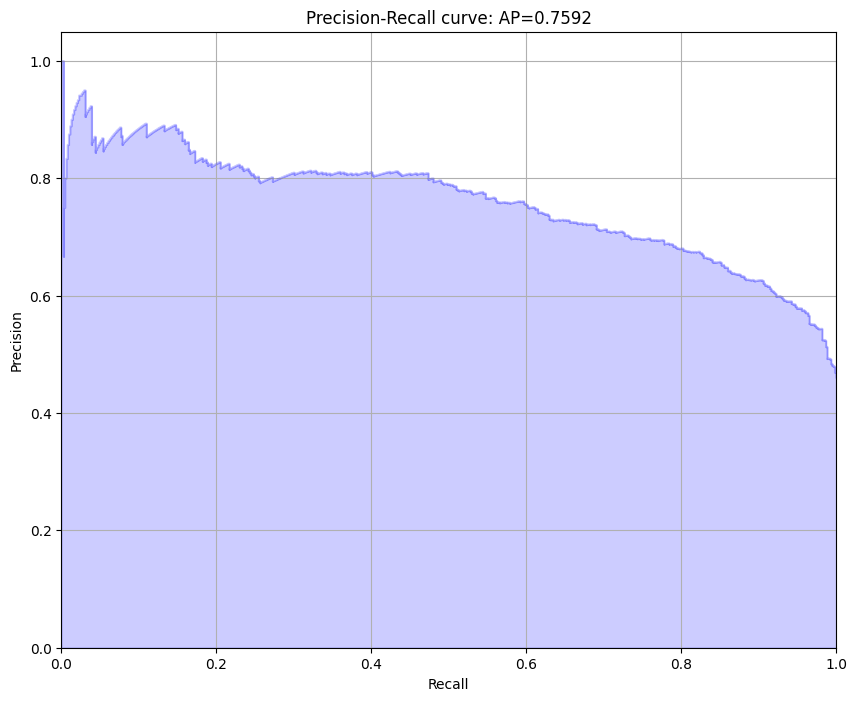

In [ ]:
# Get probabilities from your model
probabilities = model.predict(test_ds)

# If probabilities shape is (n_samples, 2), take the second column
if len(probabilities.shape) > 1 and probabilities.shape[1] == 2:
    y_probs = probabilities[:, 1]
else:
    # If it's a single column from sigmoid activation
    y_probs = probabilities.flatten()

# Calculate PR-AUC with confidence interval
pr_auc, ci, plot_function = calculate_pr_auc_confidence_interval(true_labels.astype(int), y_probs, stratify=True)

# If you want to see the PR curve visualization
plot_function()

In [ ]:
if do_binary or do_banks_binary:
    # Analyze with class 1 as positive
    results_class1 = analyze_thresholds(true_labels, [p[0] for p in predictions], positive_class=1)
    print("\nMetrics considering class 1 as positive:")
    threshold_df = results_class1.style.set_properties(**{'text-align': 'center'})
    display(threshold_df)

    # Analyze with class 0 as positive
    results_class0 = analyze_thresholds(true_labels, [p[0] for p in predictions], positive_class=0)
    print("\nMetrics considering class 0 as positive:")
    threshold_df = results_class0.style.set_properties(**{'text-align': 'center'})
    display(threshold_df)
else:
  threshold_results = create_threshold_table(predictions, true_labels)

  # Display results
  df_results = pd.DataFrame(threshold_results)
  threshold_df = df_results.style.set_properties(**{'text-align': 'center'})
  display(threshold_df)


Metrics considering class 1 as positive:


,threshold,precision,recall,f1,accuracy
0,0.050000,0.236000,0.991000,0.381000,0.614000
1,0.100000,0.500000,0.976000,0.661000,0.880000
2,0.150000,0.633000,0.965000,0.765000,0.929000
3,0.200000,0.709000,0.956000,0.814000,0.948000
4,0.250000,0.762000,0.946000,0.844000,0.958000
5,0.300000,0.802000,0.936000,0.864000,0.965000
6,0.350000,0.836000,0.923000,0.878000,0.969000
7,0.400000,0.860000,0.905000,0.882000,0.971000
8,0.450000,0.883000,0.886000,0.884000,0.972000
9,0.500000,0.899000,0.867000,0.883000,0.973000



Metrics considering class 0 as positive:


,threshold,precision,recall,f1,accuracy
0,0.050000,0.896000,1.000000,0.945000,0.898000
1,0.100000,0.933000,1.000000,0.965000,0.937000
2,0.150000,0.948000,0.999000,0.973000,0.951000
3,0.200000,0.958000,0.998000,0.978000,0.960000
4,0.250000,0.965000,0.996000,0.980000,0.965000
5,0.300000,0.969000,0.995000,0.982000,0.968000
6,0.350000,0.973000,0.994000,0.983000,0.970000
7,0.400000,0.977000,0.992000,0.984000,0.972000
8,0.450000,0.979000,0.989000,0.984000,0.972000
9,0.500000,0.982000,0.987000,0.984000,0.973000


###Does not use argmax

Confusion matrix was built with argmax. The threshold table is built using thresholds on class 0. Precision, Recall, etc. will be slighly different.

In [ ]:
# Build the threshold table
threshold_results = create_threshold_table(predictions, true_labels)

# Display results
df_results = pd.DataFrame(threshold_results)
threshold_df = df_results.style.set_properties(**{'text-align': 'center'})
threshold_df

,threshold,true_positives,false_positives,true_negatives,false_negatives,precision,recall,f1_score,specificity
0,0.000000,3954,119,0,0,0.971000,1.000000,0.985000,0.000000
1,0.100000,577,116,3,3377,0.833000,0.146000,0.248000,0.025000
2,0.200000,179,110,9,3775,0.619000,0.045000,0.084000,0.076000
3,0.300000,95,92,27,3859,0.508000,0.024000,0.046000,0.227000
4,0.400000,63,84,35,3891,0.429000,0.016000,0.031000,0.294000
5,0.500000,29,73,46,3925,0.284000,0.007000,0.014000,0.387000
6,0.600000,18,59,60,3936,0.234000,0.005000,0.009000,0.504000
7,0.700000,11,51,68,3943,0.177000,0.003000,0.005000,0.571000
8,0.800000,4,34,85,3950,0.105000,0.001000,0.002000,0.714000
9,0.900000,0,19,100,3954,0.000000,0.000000,0.000000,0.840000


In [ ]:
foobar()  #to stop runall here before save model

NameError: name 'foobar' is not defined

###Save trained model

Need save_model to capture all the nuances of the model.

In [ ]:
model_name = 'PEG_Stage1_3'

model.save(f"/content/{model_name}.keras")
%cp -r $f'/content/{model_name}.keras' /content/drive/MyDrive/salt_marsh/tiles/epa_project/essex_tile_data/saved_models/

###Should fix this up

Have to decide which threshold table to use for binary: class 0 or class 1.

In [ ]:
if do_binary or do_banks_binary:
  results_class0.to_csv(f'/content/{model_name}_threshold.csv')  #defaulting to class 0 as positive
else:
  df_results.to_csv(f'/content/{model_name}_threshold.csv')
%cp -r $f'/content/{model_name}_threshold.csv' /content/drive/MyDrive/salt_marsh/tiles/epa_project/essex_tile_data/saved_models/


In [ ]:
conf_matrix_df.to_csv(f'/content/{model_name}_confusion.csv')
%cp -r $f'/content/{model_name}_confusion.csv' /content/drive/MyDrive/salt_marsh/tiles/epa_project/essex_tile_data/saved_models/


#Post-processing

Lots of ideas here. See me for code if get this far.